In [ ]:
Advertising Veri Seti ile Satış Tahmini
Projenin Amacı
Bu çalışmanın amacıreklam harcamalarının satış miktarı üzerindeki etkisini
incelemek ve satış değerlerini tahmin etmek için Karar Ağacı Regresyonmodelini uygulamaktır
Model farklı reklam kanallarına yapılan harcamalara göre satış miktarını tahmin etmeyi öğrenmektedir
Advertising veri seti aşağıdaki değişkenleri içermektedir
TV → TV reklam bütçesi
Radio → Radyo reklam bütçesi
Newspaper → Gazete reklam bütçesi
Sales → Satış miktarı (hedef değişke
Bu çalışmada Advertising veri seti kullanılarak Karar Ağacı Regresyon modeli kurulmuştur
Model, reklam harcamalarına göre satış tahmini yapmayı öğrenmiştir
Ağaç derinliği sınırlandırılarak aşırı öğrenme problemi azaltılmıştır
Elde edilen R² skoru modelin satış tahmininde başarılı olduğunu göstermektedir

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data = pd.read_csv(r"C:\Users\ertur\OneDrive\Desktop\Advertising (1).csv")
print(data.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [9]:
data = data.drop("Unnamed: 0", axis=1)

In [10]:
X = data.drop("Sales", axis=1)
y = data["Sales"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 3.3262093699081134
R2 Score: 0.8946188004999236


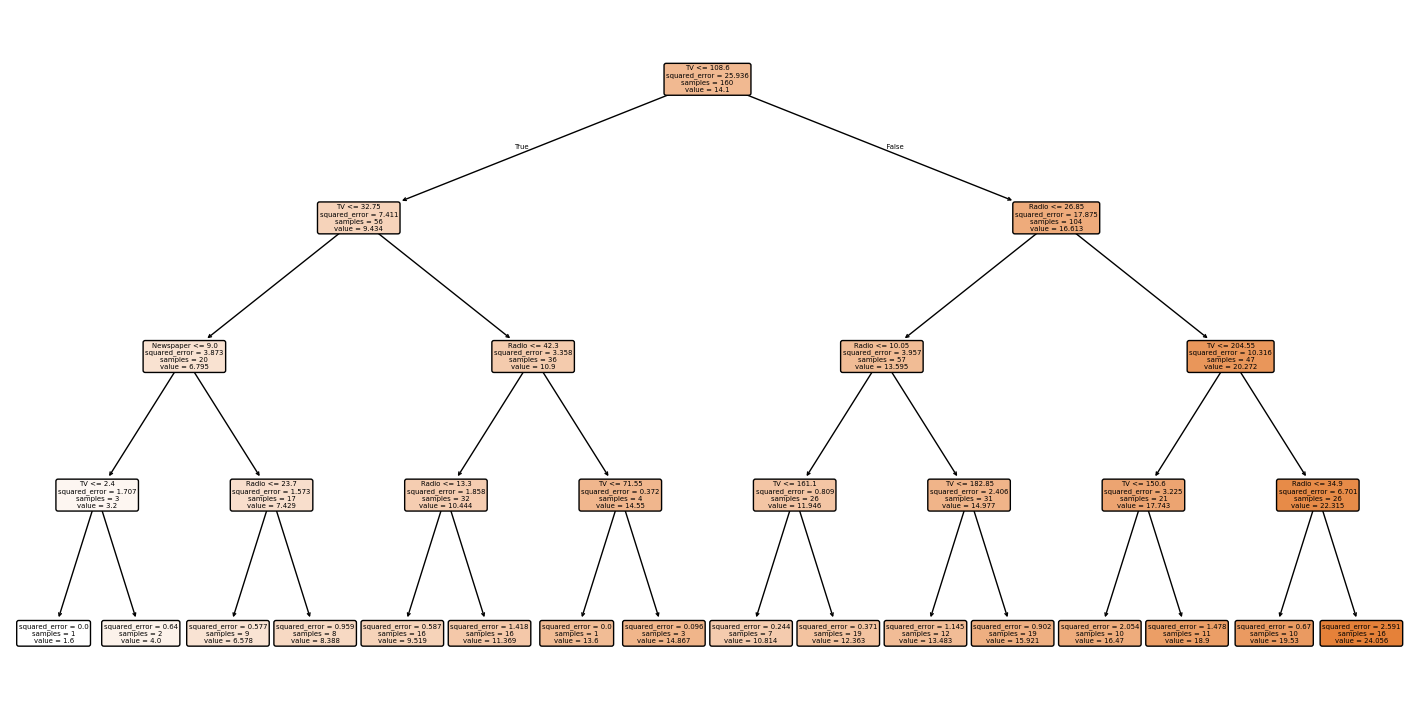

In [15]:
plt.figure(figsize=(18,9))
plot_tree(model,
          feature_names=X.columns,
          filled=True,
          rounded=True)
plt.show()

In [16]:
importance = model.feature_importances_
for i,v in enumerate(importance):
    print(X.columns[i], ":", v)

TV : 0.6100616424294129
Radio : 0.37847377979482916
Newspaper : 0.011464577775758081
